In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('src')

from signal_generator import generate_thz_signal, double_debye_permittivity

clean_signals = np.load('data/simulated_clean/signals.npy')
glucose_labels = np.load('data/simulated_clean/glucose_labels.npy')
freq_axis = np.load('data/simulated_clean/freq_axis.npy')

print(f"Signals shape  : {clean_signals.shape}")
print(f"Glucose labels : {glucose_labels.shape}")
print(f"Freq axis      : {freq_axis.shape}")
print(f"Freq range     : {freq_axis[0]:.2f} – {freq_axis[-1]:.2f} THz")

Signals shape  : (1000, 512)
Glucose labels : (1000,)
Freq axis      : (512,)
Freq range     : 0.10 – 1.00 THz


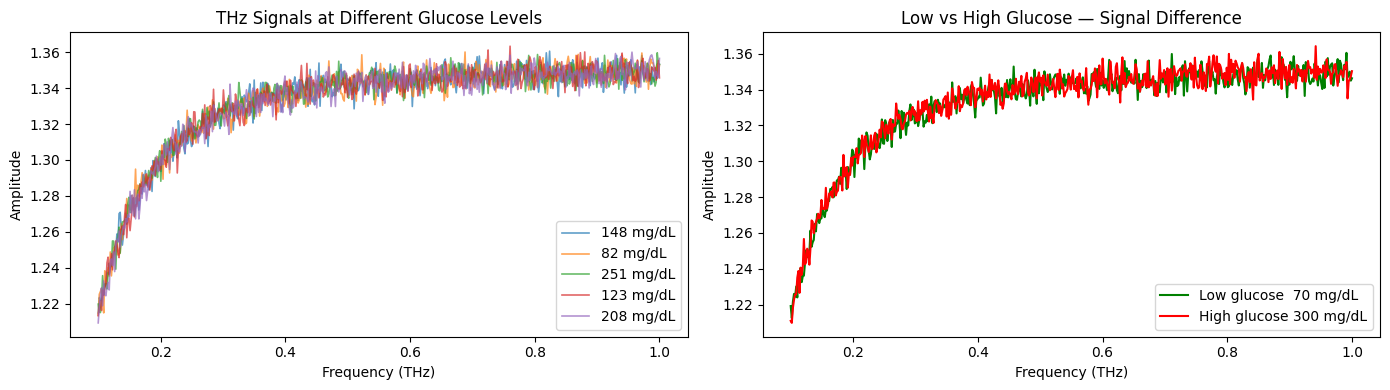

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i in [0, 50, 100, 200, 300]:
    axes[0].plot(freq_axis, clean_signals[i], alpha=0.7, linewidth=1.2)

axes[0].set_title('THz Signals at Different Glucose Levels')
axes[0].set_xlabel('Frequency (THz)')
axes[0].set_ylabel('Amplitude')
axes[0].legend([f'{glucose_labels[i]:.0f} mg/dL' for i in [0, 50, 100, 200, 300]])

low_idx  = np.argmin(glucose_labels)
high_idx = np.argmax(glucose_labels)

axes[1].plot(freq_axis, clean_signals[low_idx],  label=f'Low glucose  {glucose_labels[low_idx]:.0f} mg/dL',  color='green')
axes[1].plot(freq_axis, clean_signals[high_idx], label=f'High glucose {glucose_labels[high_idx]:.0f} mg/dL', color='red')
axes[1].set_title('Low vs High Glucose — Signal Difference')
axes[1].set_xlabel('Frequency (THz)')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/01_clean_signals.png', dpi=150)
plt.show()

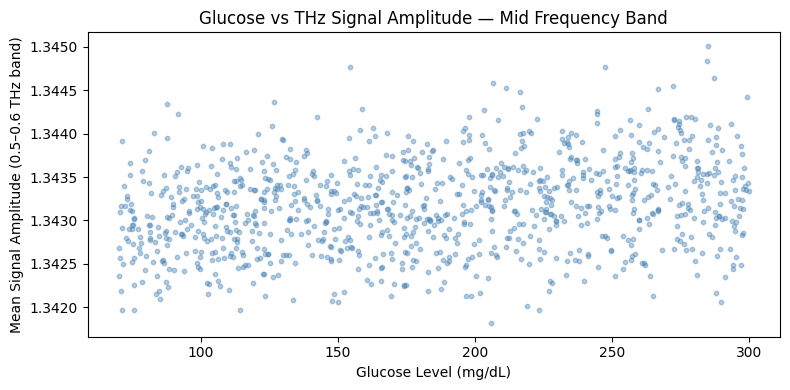

In [5]:
mid_freqs = np.mean(clean_signals[:, 200:300], axis=1)

plt.figure(figsize=(8, 4))
plt.scatter(glucose_labels, mid_freqs, alpha=0.4, s=10, color='steelblue')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Mean Signal Amplitude (0.5–0.6 THz band)')
plt.title('Glucose vs THz Signal Amplitude — Mid Frequency Band')
plt.tight_layout()
plt.savefig('results/figures/01_glucose_vs_amplitude.png', dpi=150)
plt.show()
